## Customer Support Ticket Intelligence

An NLP project on customer support tickets, built from scratch to learn text classification and semantic search along the way. Two things get predicted from raw ticket text: which department a ticket should go to (`queue`), and how urgent it is (`priority`). A later stage adds similar-ticket search, so a new ticket can be matched against how similar tickets were resolved in the past.

**Data:** two overlapping-but-distinct exports of a multilingual customer support ticket dataset (`customer_support1.csv` and `customer_support2.csv` correspond to the "aa_dataset" and "3-4k" versions of the source Kaggle dataset). This notebook combines them, checks for duplicates, drops sparse columns, and restricts to English-only tickets before any actual NLP work begins.

In [1]:
#Importing the libraries

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')


In [2]:
# Importing the dataset

# We have two dataset, and if both are compatible, we will merge them as one. 

first_dataset =  pd.read_csv("customer_support1.csv")
second_dataset =  pd.read_csv("customer_support2.csv")



In [3]:
first_dataset.sample(5)

,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
16039,Sicherheit medizinischer Daten in IT-Systemen ...,"Lieber Kundensupport, ich hoffe, Sie sind in b...","Lieber <name>, ich danke Ihnen für Ihre Anfrag...",Request,Product Support,low,de,400,Security,IT,Tech Support,Documentation,Feedback,Performance,NaN,NaN
25507,Issues with Marketing-Dashboard,The Marketing-Dashboard is experiencing outage...,"Dear <name>,\n\nI am writing to address the re...",Incident,Technical Support,high,de,400,Outage,Performance,Bug,IT,Tech Support,NaN,NaN,NaN
22049,NaN,"Hello Customer Support, I am reaching out to i...","Hello, we would be happy to help you optimize ...",Request,IT Support,high,en,400,Feedback,Sales,IT,Tech Support,NaN,NaN,NaN,NaN
21658,Trouble with Network Connections,Problems with devices linking to the WLAN-Rout...,"To address the network connection issues, more...",Incident,Technical Support,medium,en,400,Network,Performance,Disruption,IT,Tech Support,NaN,NaN,NaN
21048,Unrecognized Access Attempt on Hospital System,There has been an unauthorized access attempt ...,Regarding your concern about the unauthorized ...,Incident,Product Support,low,en,400,Security,Alert,IT,Tech Support,NaN,NaN,NaN,NaN


In [4]:
second_dataset.sample(5)

,subject,body,answer,type,queue,priority,language,business_type,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8,tag_9
382,Battery Issue with Surface Pro,"Dear Tech Online Store Customer Support,\n\nI ...","Dear <name>,\n\nThank you for reaching out to ...",Incident,Product Support,medium,en,Tech Online Store,Technical Support,Product Support,Hardware Failure,Warranty Claim,Problem Resolution,Service Recovery,NaN,NaN,NaN
1523,Buscando Asistencia Inmediata para el Problema...,"Estimado equipo de soporte al cliente, espero ...","Estimado <name>,\n\nGracias por contactarnos r...",Incident,Customer Service,medium,es,IT Services,Technical Support,Product Support,Hardware Failure,Problem Resolution,Urgent Issue,Service Recovery,NaN,NaN,NaN
1536,Solicitud para modificar flujos de trabajo de ...,"Estimado equipo de soporte al cliente,\n\nEspe...","Estimado <name>,\n\nGracias por comunicarse co...",Change,Technical Support,high,es,Software Development Company,Technical Support,Product Support,Technical Guidance,Problem Resolution,General Inquiry,Software Bug,NaN,NaN,NaN
3891,Asistencia Urgente para el Rendimiento del Ser...,"Estimado equipo de atención al cliente,\n\nEst...",Asunto: Re: Asistencia Urgente para el Rendimi...,Request,Technical Support,high,es,IT Consulting Firm,Urgent Issue,Performance Tuning,Technical Support,Problem Resolution,System Maintenance,IT Support,NaN,NaN,NaN
2546,Request for Additional Server Administration,"Hello Customer Support,\n\nI hope this message...","Hello,\n\nThank you for reaching out. We’re pl...",Request,IT Support,medium,en,IT Consulting Firm,IT Support,Technical Guidance,Account Assistance,General Inquiry,Service Notification,NaN,NaN,NaN,NaN


In [5]:
print(first_dataset.shape)
print(second_dataset.shape)

(28587, 16)
(4000, 17)


In [6]:
print(first_dataset.columns)
print(second_dataset.columns)

Index(['subject', 'body', 'answer', 'type', 'queue', 'priority', 'language',
       'version', 'tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6',
       'tag_7', 'tag_8'],
      dtype='str')
Index(['subject', 'body', 'answer', 'type', 'queue', 'priority', 'language',
       'business_type', 'tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6',
       'tag_7', 'tag_8', 'tag_9'],
      dtype='str')


### Comparing the source datasets

Before combining, checking whether the two datasets' schemas line up. Both have the same core fields - ticket text, type, queue, priority, language, tags - with a few source-specific columns: `version` only in the first, `business_type` and `tag_9` only in the second. `pandas.concat()` aligns by column name, so they combine safely; anything missing from one source just becomes NaN.

### Combining and cleaning the two source files

In [7]:
complete_dataset = pd.concat([first_dataset, second_dataset], ignore_index=True)
complete_dataset.shape

(32587, 18)

In [8]:
df = complete_dataset.copy()

In [9]:
# Taking a look at the dataset

df.head()

,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8,business_type,tag_9
0,Wesentlicher Sicherheitsvorfall,"Sehr geehrtes Support-Team,\n\nich möchte eine...",Vielen Dank für die Meldung des kritischen Sic...,Incident,Technical Support,high,de,51.0,Security,Outage,Disruption,Data Breach,NaN,NaN,NaN,NaN,NaN,NaN
1,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...","Thank you for reaching out, <name>. We are awa...",Incident,Technical Support,high,en,51.0,Account,Disruption,Outage,IT,Tech Support,NaN,NaN,NaN,NaN,NaN
2,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Thank you for your inquiry. Our products suppo...,Request,Returns and Exchanges,medium,en,51.0,Product,Feature,Tech Support,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",We appreciate you reaching out with your billi...,Request,Billing and Payments,low,en,51.0,Billing,Payment,Account,Documentation,Feedback,NaN,NaN,NaN,NaN,NaN
4,Question About Marketing Agency Software Compa...,"Dear Support Team,\n\nI hope this message reac...",Thank you for your inquiry. Our product suppor...,Problem,Sales and Pre-Sales,medium,en,51.0,Product,Feature,Feedback,Tech Support,NaN,NaN,NaN,NaN,NaN,NaN


### Initial data inspection

Before any cleaning or feature engineering, a first look at size, structure, dtypes, missing values, and potential duplicates - a baseline before touching anything.

In [10]:
# shape of the dataset

df.shape

(32587, 18)

The combined dataset has **32,587 tickets and 18 columns** - a reasonable amount for training NLP classifiers, though the usable count may shrink once problematic records get filtered out.

In [11]:
# Check the datatypes of each feature

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32587 entries, 0 to 32586
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   subject        28282 non-null  str    
 1   body           32586 non-null  str    
 2   answer         32580 non-null  str    
 3   type           32587 non-null  str    
 4   queue          32587 non-null  str    
 5   priority       32587 non-null  str    
 6   language       32587 non-null  str    
 7   version        28587 non-null  float64
 8   tag_1          32587 non-null  str    
 9   tag_2          32574 non-null  str    
 10  tag_3          32451 non-null  str    
 11  tag_4          29528 non-null  str    
 12  tag_5          17908 non-null  str    
 13  tag_6          8055 non-null   str    
 14  tag_7          3085 non-null   str    
 15  tag_8          834 non-null    str    
 16  business_type  4000 non-null   str    
 17  tag_9          0 non-null      float64
dtypes: float64(2), st

### Checking for duplicate tickets

Since the two files were just combined, duplicates could exist across them. A full-row check isn't reliable here since some source-specific metadata differs between files, so `body` is used as the identifier instead - matching bodies get treated as duplicates.

In [12]:
df.duplicated(subset='body').sum()

np.int64(0)

No duplicate ticket bodies found - the two source datasets don't appear to overlap.

### Missing value analysis

Next: how much is missing from each column. A few missing text values can be dropped or filled safely; columns that are mostly missing may not be worth keeping at all.

In [13]:
# Check for the null values

df.isnull().sum()

subject           4305
body                 1
answer               7
type                 0
queue                0
priority             0
language             0
version           4000
tag_1                0
tag_2               13
tag_3              136
tag_4             3059
tag_5            14679
tag_6            24532
tag_7            29502
tag_8            31753
business_type    28587
tag_9            32587
dtype: int64

Several features carry a heavy amount of NaN. Checking the percentage missing per feature next, to decide what's worth keeping.

In [14]:
# Percentage of missing values

df.isnull().sum()/len(df)*100

subject           13.210790
body               0.003069
answer             0.021481
type               0.000000
queue              0.000000
priority           0.000000
language           0.000000
version           12.274834
tag_1              0.000000
tag_2              0.039893
tag_3              0.417344
tag_4              9.387179
tag_5             45.045570
tag_6             75.281554
tag_7             90.533035
tag_8             97.440697
business_type     87.725166
tag_9            100.000000
dtype: float64

### Identifying sparse features

The missing-value check turns up several highly sparse columns:

- `tag_9` is completely empty.
- `tag_8` is missing for over 97% of records.
- `tag_7` is missing for over 90%.
- `tag_6` is missing for over 75%.
- `business_type` is missing for ~88%.
- `tag_5` is missing for ~45%.

Rather than imputing large amounts of artificial data, these get excluded from the initial pipeline. The rest get evaluated individually.

#### Investigating the `version` feature

In [15]:
# checking feature -> Version

df["version"].value_counts()

version
400.0    18599
52.0      9119
51.0       869
Name: count, dtype: int64

`version` only takes a handful of distinct values (mainly `400`, `52`, `51`) - looks like source/dataset metadata rather than anything about the ticket itself, so it's dropped.

### Removing low-value features

Based on the missingness check and `version`, these get dropped from the initial modeling dataset: `business_type`, `tag_5`, `tag_6`, `tag_7`, `tag_8`, `tag_9`, `version`.

Not a permanent verdict on these columns - just excluded from the initial NLP pipeline given their sparsity or limited relevance. The core task will run on what's consistently available across tickets.

In [16]:
columns_to_drop = ['business_type', 'tag_5', 'tag_6',
                    'tag_7', 'tag_8', 'tag_9', 'version']

df = df.drop(columns=columns_to_drop)

### Investigating the `language` column

The dataset spans multiple languages, and this project only trains on English tickets. But the `language` column shouldn't be trusted blindly - a few manually inspected rows already look mislabeled. Rather than filtering on the label directly, I'll detect the language independently from the ticket text and compare the two.

In [17]:
# checking feature -> Language

df["language"].value_counts()

language
en    17729
de    13097
es      812
fr      476
pt      473
Name: count, dtype: int64

In [18]:
pd.set_option('display.max_colwidth', None)
df[df["language"] == "en" ].sample(3)

,subject,body,answer,type,queue,priority,language,tag_1,tag_2,tag_3,tag_4
26396,Customer Support Inquiry on Integration of Data Analytics Tools,"Greetings from the Customer Support team. We are writing to request detailed information on the integration of data analytics tools across the affected products. This integration aims to enhance investment optimization decision-making capabilities. Our goal is to provide a comprehensive understanding of market trends and customer behavior, which will support informed business decisions. We believe this integration will have a significant impact on the business and would like to discuss it with your team. Please let us know if there is anything we can implement next and provide the necessary steps. We look forward to your response.","Hello, thank you for reaching out to our Customer Support team regarding the integration of data analytics tools across affected products. We appreciate your interest in enhancing investment optimization decision-making capabilities. To better understand your requirements, could you please provide specific information on the products and the analytics tools you are referring to? This will enable us to assess the feasibility of the integration and provide a detailed response. If necessary, we can schedule a call at <tel_num> to discuss this further. We will review your request promptly.",Change,IT Support,medium,en,Feedback,Product,Feature,IT
22066,Support Request for Data Inconsistency,"The team is encountering data inconsistency issues while using Excel 2021 to analyze investment data, which may be related to integration conflicts with MySQL. We've already attempted to refresh the data connections and reboot the WLAN router, but the inconsistency still persists.","We are here to assist with the data inconsistency issues in Excel 2021. I'm sorry to hear that refreshing the data connections and rebooting the WLAN router did not resolve the issue. To better understand the problem, could you please provide more details about your integration setup with MySQL and the nature of the inconsistencies you are experiencing? Additionally, it would be helpful to know the version of MySQL and any relevant software plugins that are involved. If needed, we can schedule a call at a convenient time to discuss and explore possible solutions together. Please provide the necessary details.",Problem,Product Support,medium,en,Bug,Network,Performance,IT
11170,Challenge with Marketing Campaign Effectiveness,marketing initiatives are currently performing satisfactorily.,examine the marketing campaigns by contacting us at <tel_num> to discuss the poor performance issue and explore potential solutions together <acc_num>.,Problem,Sales and Pre-Sales,medium,en,Feedback,Sales,Performance,NaN


In [19]:
df[df["language"] == "de" ].sample(5)

,subject,body,answer,type,queue,priority,language,tag_1,tag_2,tag_3,tag_4
2548,QuickBooks und Dynamics-Abonnementoptionen,"Sehr geehrter Kundenservice, ich möchte mich nach den verfügbaren Abonnementmöglichkeiten für QuickBooks Online und Microsoft Dynamics 365 erkundigen. Könnten Sie bitte detaillierte Informationen zu den verfügbaren Tarifen bereitstellen, einschließlich Preise, Funktionen und möglicher Rabatte? Besonders interessiert bin ich daran, die Unterschiede zwischen den verschiedenen Plänen zu verstehen, um den am besten auf die spezifischen Bedürfnisse unseres Unternehmens zugeschnittenen Plan auszuwählen. Zudem wäre eine Anleitung hilfreich, um den geeignetsten Plan basierend auf Unternehmensgröße und Branche zu bestimmen. Bitte fügen Sie relevante Links und Ressourcen bei, die ich nutzen kann.","<name>, vielen Dank, dass Sie das Kundenserviceteam bezüglich der Abonnementpläne für QuickBooks und Dynamics kontaktiert haben. Wir bieten verschiedene Pläne mit unterschiedlichen Preisen und Funktionen an, die auf die Bedürfnisse Ihres Unternehmens zugeschnitten sind. Für genauere Informationen bitten wir Sie, uns Details zu Unternehmensgröße und Branche mitzuteilen. Gerne können wir auch ein telefonisches Gespräch führen. Wäre ein passender Zeitpunkt für einen Anruf? Alternativ senden wir Ihnen die Informationen auch gerne per E-Mail, um den Einstieg zu erleichtern.",Request,Billing and Payments,medium,de,Product,Subscription,Pricing,Feature
18319,Customer Support Digital Growth Strategies,"Provide details on digital strategies, promote brand growth, and discuss the impact on Magento?","contact, discuss digital strategies for growth in Magento",Request,Technical Support,medium,de,Feedback,Sales,IT,Tech Support
18547,Unterstützung bei digitalen Strategien für Markenwachstum,"Hallo [Name], vielen Dank, dass Sie sich für mehr Informationen zu unseren Markenwachstumsdienstleistungen interessieren. Wir freuen uns, Ihnen detaillierte Informationen über spezifische Taktiken und Techniken zur Verfügung zu stellen, die für den Wachstum Ihres Geschäfts hilfreich sind. Unsere Dienstleistungen umfassen Sozialmedienmanagement, Inhaltserschaffung und zielgerichtete Werbung. Wir werden eine angepasste Strategie erstellen, die Ihren Geschäftsanforderungen entspricht. Falls Sie ein Gespräch einlegen möchten, teilen Sie bitte ein geeignetes Zeitfenster mit. Sie können uns anrufen, um die Dienstleistungen für Ihr Konto [acc_num] weiter auszuhören. [tel_num]","geehrte [Name], vielen Dank, dass Sie sich für unsere Markenwachstumsdienstleistungen interessieren. Wir freuen uns, Ihnen mehr Informationen zu spezifischen Taktiken und Techniken zur Verfügung zu stellen, die für den Wachstum Ihres Geschäfts hilfreich sind. Unsere Dienstleistungen umfassen Sozialmedienmanagement, Inhaltserschaffung und zielgerichtete Werbung. Wir werden eine angepasste Strategie erstellen, die Ihren Geschäftsanforderungen entspricht. Falls ein Gespräch in Betracht gezogen wird, teilen Sie bitte ein geeignetes Zeitfenster mit, um anzurufen und die Dienstleistungen für Ihr Konto [acc_num] auszuhören. [tel_num]",Request,Product Support,medium,de,Feedback,Sales,IT,NaN
24353,NaN,"geehrte Kundenservice, <br><br>ich schreibe, um einen schwerwiegenden Vorfall zu melden, der einen Datensperrverstoß in Gesundheitsversorgungssystemen umfasst. Es sind sensible medizinische Daten ausgesetzt, was ich vermute, aufgrund veralteter Sicherheitsprotokolle. Trotz bereits unternommener Maßnahmen, wie das Aktualisieren der Antivirus-Software und die Durchführung der ersten Sicherheitsprüfungen, bestehen Probleme weiterhin. <br><br>Wir sind besorgt über die möglichen Konsequenzen des Verstoßes und möchten your Hilfe in der schnellen Behebung der Angelegenheit bitten. Ihre Unterstützung wäre sehr geschätzt, und wir sind bereit, alles zu tun, um die Situation zu verbessern.","geehrte [Name], ich möchte Ihnen mitteilen, dass ich Ihren E-Mail-Bericht über den Datensperrverstoß in Gesundheit

In [20]:
pd.set_option('display.max_colwidth', None)
df[df["language"] == "es" ].sample(3)

,subject,body,answer,type,queue,priority,language,tag_1,tag_2,tag_3,tag_4
31457,Solicitud de soporte para problemas de Adobe Photoshop,"Estimado servicio de atención al cliente,\n\nEstoy experimentando bloqueos persistentes con Adobe Photoshop 2024, especialmente cuando intento editar cualquier proyecto. ¿Podrían ayudarme a solucionar estos problemas? Gracias por su pronta atención a este asunto.\n\nAtentamente,\n<name>","Estimado <name>, lamentamos los inconvenientes. Por favor, intente actualizar Photoshop a la última versión, verifique si hay actualizaciones de controladores gráficos, asegúrese de tener suficiente espacio en disco y restablezca las preferencias de Photoshop. Si los problemas persisten, no dude en proporcionar más detalles.",Problem,Technical Support,medium,es,Technical Support,Software Bug,Problem Resolution,Product Support
31902,NaN,"Hola,\n\n¿Podrías por favor verificar la disponibilidad y los precios para el MacBook Air M1, tanto en línea como en la tienda? Espero tu respuesta. ¡Gracias!\n\nSaludos cordiales,\n<name>","Hola <name>,\n\nGracias por tu consulta. Puedes encontrar la disponibilidad y los precios para el MacBook Air M1 en nuestro sitio web o visitando tu tienda más cercana. Ten en cuenta que la disponibilidad en línea puede diferir del stock en tienda. No dudes en contactarnos si necesitas más asistencia.\n\nSaludos cordiales,\nEquipo de Atención al Cliente",Request,Customer Service,low,es,Sales Inquiry,Product Support,Customer Service,General Inquiry
29003,Necesito asistencia con la configuración inalámbrica del HP DeskJet 3755,"Estimado servicio de atención al cliente,\n\nRecientemente compré un HP DeskJet 3755 en su tienda en línea y tengo problemas para conectar su función inalámbrica. ¿Podría ayudarme con la configuración? Gracias por su ayuda.\n\nSaludos cordiales,\n<name>\n<acc_num>","Estimado <name>,\n\nGracias por contactarnos. Para configurar su HP DeskJet 3755 de forma inalámbrica, descargue la aplicación HP Smart, elija ""Configurar una nueva impresora"" y siga las instrucciones en la pantalla. Si necesita más ayuda, no dude en contactarnos.\n\nSaludos cordiales,\nServicio de atención al cliente",Request,Product Support,low,es,Technical Support,Product Support,Customer Service,Problem Resolution


In [21]:
pd.set_option('display.max_colwidth', None)
df[df["language"] == "fr" ].sample(3)

,subject,body,answer,type,queue,priority,language,tag_1,tag_2,tag_3,tag_4
30578,Problèmes de connectivité avec l'imprimante HP DeskJet 3755,"Bonjour, j'éprouve des problèmes de connectivité avec mon imprimante HP DeskJet 3755. Elle ne se connecte pas sans fil à mes appareils. Cela s'est produit après la dernière mise à jour du firmware. Veuillez m'aider à résoudre ce problème. Merci. Cordialement, <name>.","Bonjour <name>, essayez de redémarrer votre imprimante et votre routeur. Assurez-vous que le Wi-Fi est activé et reconnectez l'imprimante à l'aide de l'application HP Smart. Si le problème persiste, réinitialisez les paramètres réseau de l'imprimante. Faites-nous savoir si vous avez besoin d'une assistance supplémentaire.",Problem,Technical Support,low,fr,Technical Support,Hardware Failure,IT Support,Problem Resolution
31050,Signaler des problèmes liés à l'utilisation de Jira Software,"Cher service client,\n\nJe vous écris pour vous informer de certains problèmes rencontrés par notre équipe de vente avec Jira Software 8.20 concernant le suivi de la gestion de projet. Nous avons rencontré des difficultés considérables lors de la mise à jour des tâches et de l'affichage des tableaux de bord de manière efficace, ce qui entrave nos processus de travail. Notre équipe dépend fortement de ces fonctionnalités pour maintenir sa productivité, et ce problème a créé des goulots d'étranglement.\n\nLes tâches semblent soit ne pas être correctement enregistrées, soit se mettre à jour avec des retards significatifs, causant confusion et efforts duplicés au sein de l'équipe. De plus, les tableaux de bord mettent plus de temps que d'habitude à se charger, souvent sans refléter les informations les plus à jour. Cela a influencé notre processus de prise de décision, car nous comptons sur une représentation précise des données.\n\nNous vous prions de bien vouloir nous aider à résoudre ces problèmes dans les meilleurs délais. La fonctionnalité de notre équipe de vente dépend considérablement du bon fonctionnement du système de suivi de la gestion de projet.\n\nMerci de votre attention à ce sujet. Dans l'attente de votre réponse rapide.\n\nCordialement,\n\n<name>\n<acc_num>\n<tel_num>","Cher <name>,\n\nMerci de nous avoir contactés concernant les problèmes que votre équipe de vente rencontre avec Jira Software 8.20. Nous comprenons l'importance d'un flux de travail fluide dans votre gestion de projet et l'inconvénient causé par ces problèmes.\n\nPour vous aider efficacement, veuillez vous assurer que votre instance Jira est mise à jour vers la dernière version, car les mises à jour incluent souvent des corrections de bogues et des améliorations de performance. De plus, vider le cache et vérifier vos connexions réseau pourrait aider avec les temps de chargement et la réflexion des données.\n\nNous vous suggérons de vérifier vos paramètres de journalisation pour voir s'il y a des erreurs enregistrées lorsque les tâches échouent à se mettre à jour ou lorsque les tableaux de bord se chargent lentement. En outre, examinez toutes les personnalisation ou plugins qui pourraient affecter les performances.\n\nSi le problème persiste, veuillez nous fournir tous messages d'erreur ou captures d'écran, car cela nous aidera à diagnostiquer le problème plus précisément. Notre équipe technique est prête à vous aider davantage à résoudre ce problème rapidement.\n\nDans l'attente de votre réponse.\n\nCordialement,\nÉquipe de support client",Incident,Sales and Pre-Sales,medium,fr,Technical Support,Software Bug,Problem Resolution,System Maintenance
29636,Demande de détails sur le MacBook Air M1,"Cher équipe de support client,\n\nJ'espère que ce message vous trouve bien. J'ai récemment acquis un MacBook Air M1 auprès de Tech Online Store, et je recherche des informations détaillées sur son utilisation et quelques étapes de dépannage initiales. Bien que l'appareil fonctionne bien dans l'ensemble, je suis un nouveau venu dans l'écosystème Mac, et il serait bénéfique d'a

In [22]:
pd.set_option('display.max_colwidth', None)
df[df["language"] == "pt" ].sample(3)

,subject,body,answer,type,queue,priority,language,tag_1,tag_2,tag_3,tag_4
30243,Problema de Cobrança Inconsistente com o AWS Management,"Caro Time de Suporte ao Cliente,\n\nEstou escrevendo para solicitar assistência com a cobrança inconsistente vista na nossa conta do AWS Management Service <acc_num>. Suspeitamos que uma alocação de recursos subótima possa ser a causa e precisamos de orientação sobre estratégias eficientes de gerenciamento de custos. Sua ajuda oportuna para otimizar os custos seria muito apreciada. Por favor, entre em contato comigo pelo <tel_num> ou e-mail <email>.\n\nObrigado,\n\n<name>","Caro <name>,\n\nObrigado por entrar em contato sobre suas preocupações com a cobrança na conta do AWS Management Service. Entendemos o quanto a gestão eficiente de custos é importante para suas operações. Nossa equipe investigará o assunto e oferecerá orientação sobre a otimização da alocação de recursos para ajudar a reduzir custos. Entraremos em contato em breve pelo seu número de telefone ou e-mail fornecido para discutir mais.\n\nAtenciosamente,\nTime de Suporte ao Cliente",Incident,Customer Service,low,pt,Billing Issue,Customer Service,Account Assistance,Technical Guidance
28920,Problemas técnicos com os recursos de vídeo e compartilhamento de tela do Zoom 5.11.0,"Caro(a) Equipe de Suporte ao Cliente de Serviços de TI,\n\nEspero que esta mensagem o(a) encontre bem. Estou escrevendo para trazer à sua atenção alguns problemas técnicos significativos que encontrei recentemente ao usar a aplicação Zoom versão 5.11.0. Este problema é de alta prioridade, pois impacta diretamente as funcionalidades essenciais de videoconferência e compartilhamento de tela, afetando assim minhas operações diárias.\n\nEm várias ocasiões, durante reuniões agendadas no Zoom, experimentei severas interrupções. Inicialmente, a funcionalidade de vídeo falhou ao iniciar corretamente, apresentando uma tela em branco, apesar de uma conexão de internet estável. Além disso, ao tentar compartilhar minha tela, o recurso torna-se intermitentemente não responsivo, às vezes me desconectando da reunião completamente. Esses problemas persistiram mesmo após várias tentativas de resolvê-los através de etapas padrão de solução de problemas, incluindo reiniciar a aplicação, garantir que todas as atualizações estavam instaladas e verificar se todos os requisitos do sistema foram atendidos.\n\nA natureza desses problemas técnicos prejudica severamente a eficácia das reuniões virtuais, levando a desafios significativos na manutenção de uma comunicação sem interrupções com colegas e clientes. Como o Zoom é fundamental para nosso fluxo de trabalho, esse problema contínuo está causando considerável inconveniência, sem mencionar uma possível queda na produtividade.\n\nPeço a sua assistência para resolver este assunto na sua conveniência mais rápida. Se necessário, posso fornecer logs ou qualquer informação adicional que possa ajudar a diagnosticar e corrigir esses problemas. É crucial que garantamos que essas funcionalidades estejam operacionalmente confiáveis para facilitar a comunicação e colaboração ininterruptas.\n\nObrigado pela sua atenção imediata a esta questão de alta prioridade. Aguardo sua rápida resposta e uma solução viável. Sinta-se à vontade para me contatar pelos meus detalhes fornecidos.\n\nAtenciosamente,\n\n<name>","Caro(a) <name>,\n\nObrigado por entrar em contato e por trazer este problema à nossa atenção. Pedimos desculpas pela inconveniência que você está experimentando com a versão do Zoom 5.11.0, especialmente com as funções de vídeo e compartilhamento de tela.\n\nNossa equipe está comprometida em ajudá-lo a resolver esses problemas técnicos rapidamente. Com base na sua descrição, parece que uma investigação detalhada pode ser necessária. Por favor, forneça-nos quaisquer logs de erro ou informações adicionais que você puder compartilhar, pois isso nos ajudará a diagnosticar o problema com precisão.\n\nEnquanto isso, certifique-se de que os driver

#### Verifying the language labels

Scanning a few of the "de"-labeled rows, several are clearly written in English, not German - worth taking seriously, since this project's English-only boundary depends on that column being right. Running real language detection (`langdetect`) on `body` and comparing it against the `language` column: if the label were reliable, the two should match almost perfectly.

In [23]:
from langdetect import detect, DetectorFactory
DetectorFactory.seed = 42 

def safe_detect(text):
    try:
        return detect(text[:500])  # first 500 characters is enough to detect language reliably
    except:
        return 'unknown'

df['detected_language'] = df['body'].apply(safe_detect)

In [24]:
pd.crosstab(df['language'], df['detected_language'])

detected_language,af,ca,da,de,en,es,et,fr,it,nl,no,pt,ro,sv,unknown
language,,,,,,,,,,,,,,,
de,3,1,1,9739,3323,6,0,9,5,0,2,6,1,1,0
en,2,5,4,2,17665,2,1,30,7,6,0,4,0,0,1
es,0,0,0,0,0,811,0,0,0,0,0,1,0,0,0
fr,0,0,0,0,0,0,0,476,0,0,0,0,0,0,0
pt,0,0,0,0,0,0,0,0,0,0,0,473,0,0,0


### Comparing the provided and detected language

The provided `language` column isn't fully reliable. Most English-labeled tickets are detected as English, but a fair number labeled German (`de`) are actually detected as English - filtering on the original label alone would have dropped real English tickets. Going with the detected language instead for building the English-only dataset.

In [25]:
df_new = df[df['detected_language'] == 'en'].reset_index(drop=True)
df_new = df_new.drop(columns=['language', 'detected_language'])
df_new.shape

(20988, 10)

In [26]:
df_new.head()

,subject,body,answer,type,queue,priority,tag_1,tag_2,tag_3,tag_4
0,Account Disruption,"Dear Customer Support Team,\n\nI am writing to report a significant problem with the centralized account management portal, which currently appears to be offline. This outage is blocking access to account settings, leading to substantial inconvenience. I have attempted to log in multiple times using different browsers and devices, but the issue persists.\n\nCould you please provide an update on the outage status and an estimated time for resolution? Also, are there any alternative ways to access and manage my account during this downtime?","Thank you for reaching out, <name>. We are aware of the outage affecting the centralized account management system, and our technical team is actively working to resolve the issue. In the meantime, we suggest using alternative methods to manage your account, with a focus on restoring service as quickly as possible. We will provide an update as soon as the service is back online. We apologize for the inconvenience and appreciate your patience. If you have any further questions, please let us know.",Incident,Technical Support,high,Account,Disruption,Outage,IT
1,Query About Smart Home System Integration Features,"Dear Customer Support Team,\n\nI hope this message reaches you well. I am reaching out to request detailed information about the capabilities of your smart home integration products listed on your website. As a potential customer aiming to develop a seamlessly interconnected home environment, it is essential to understand how your products interact with various smart home platforms.\n\nCould you kindly provide detailed compatibility information with popular smart home ecosystems such as Amazon Alexa, Google Assistant, and Apple?","Thank you for your inquiry. Our products support integration with Amazon Alexa, Google Assistant, and Apple HomeKit. Compatibility details can differ depending on the specific item; please let us know which models you are interested in. The setup process is generally user-friendly but may require professional installation. We regularly update our software to provide enhanced features. For comprehensive information on compatibility with upcoming updates, please specify the models you are considering.",Request,Returns and Exchanges,medium,Product,Feature,Tech Support,NaN
2,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this message finds you well. I am reaching out to request clarification about the billing and payment procedures linked to my account. Recently, I observed some inconsistencies in the charges applied and would like to ensure I fully understand the billing cycle, accepted payment options, and any potential extra charges.\n\nFirstly, I would be grateful if you could provide a detailed explanation of how the billing cycle functions. Specifically, I am interested in knowing the start and end dates.\n\nThank you for your assistance regarding these billing inquiries.","We appreciate you reaching out with your billing questions. The billing period generally begins on the first day of the month and concludes on the last day, with payments due by the 10th of the following month. We accept credit cards, bank transfers, and certain online payment services; credit card transactions are typically processed the quickest. Late payments may incur fees based on the due date, and any additional processing charges depend on the chosen payment method. You can review your statements for detailed payment information.",Request,Billing and Payments,low,Billing,Payment,Account,Documentation
3,Question About Marketing Agency Software Compatibility,"Dear Support Team,\n\nI hope this message reaches you well. I am reaching out to ask about the compatibility of your products with the specific needs of marketing agencies. Our company is considering adopting these solutions to streamline our current marketing processes and wants to confirm that the products are ful

Resulting dataset: English-only tickets, with the core fields needed for classification and semantic search intact.

In [27]:
df_new.isnull().sum()

subject     2831
body           0
answer         6
type           0
queue          0
priority       0
tag_1          0
tag_2          6
tag_3         79
tag_4       2025
dtype: int64

### Handling the remaining missing values

After dropping sparse features and restricting to English tickets, only a small number of missing values remain in the core columns - handled per-column rather than with one blanket strategy.

In [28]:
df_new["subject"].nunique()

18135

In [29]:
# Well, Subject have 18k unique values, we can't "mode" the missing values. Instead we will just fill it with an empty string.

df_new["subject"] = df_new["subject"].fillna("")

In [30]:
# answer has only 6 missing values. We can drop it. 

df_new = df_new.dropna(subset=["answer"]).reset_index(drop=True)

In [31]:
df_new.isnull().sum()

subject        0
body           0
answer         0
type           0
queue          0
priority       0
tag_1          0
tag_2          6
tag_3         79
tag_4       2023
dtype: int64

### Investigating the tag features

Tags aren't part of the core text-classification task, but worth a look before deciding whether to use them: how many unique values each has, whether a few dominate, and whether they're already captured by the ticket text or targets.

In [32]:
# Now for the tags

df_new["tag_2"].value_counts()

tag_2
Performance             4254
IT                      1817
Disruption              1308
Documentation           1301
Sales                   1190
                        ... 
Password Reset             1
Payroll Issue              1
Cloud Services             1
Service Recovery           1
Service Notification       1
Name: count, Length: 250, dtype: int64

In [33]:
df_new["tag_3"].value_counts()

tag_3
IT                       4294
Tech Support             1823
Performance              1815
Disruption               1282
Feedback                 1052
                         ... 
Database Optimization       1
Database Support            1
Printer Setup               1
Consultation Request        1
Email Access                1
Name: count, Length: 369, dtype: int64

In [34]:
df_new["tag_4"].value_counts()

tag_4
Tech Support            4678
IT                      3381
Disruption               901
Recovery                 862
Documentation            819
                        ... 
Wi-Fi Connectivity         1
Cloud Deployment           1
Shipping Inquiry           1
Office 365                 1
Shipping Information       1
Name: count, Length: 483, dtype: int64

### Tag distribution

Tag columns have a large number of unique values with a long-tail distribution - a handful occur often, many appear once or twice. Using them directly would mean hundreds of sparse categorical features, and several tags look semantically close to `queue`, which risks leaking the target. Dropping tags from the initial NLP models; ticket text carries the modeling signal instead.

### Exploratory analysis

With cleaning done, next: how long tickets tend to be, how `queue` and `priority` are distributed, whether `type` differs by department, and whether priority tracks with type or department. This sets expectations for what the two classifiers will be working with.

In [35]:
df_new["body"].sample(1)

17292    Customer Support, encountered difficulties while generating a report for project management using the SaaS platform. The Smart-Steckdose and Smartsheet integrations are causing connectivity problems, which are impeding the platform's functionality. After trying to restart the affected devices, verifying network settings, and examining integration logs, the issues still persist. I suspect that a recent update might be impacting API interactions and network configurations. I would greatly appreciate it if you could look into this matter and provide a solution as soon as possible. Please.
Name: body, dtype: str

### Ticket length

Ticket length may carry signal — technical incidents might run longer than simple inquiries. Checking the character-count distribution of `body`.

In [36]:
df_new["body_length"] = df_new['body'].str.strip().str.len()

In [37]:
df_new["body_length"].describe()

count    20982.000000
mean       385.576875
std        225.219476
min         13.000000
25%        217.000000
50%        376.000000
75%        537.000000
max       2466.000000
Name: body_length, dtype: float64

Average ticket body is about **386 characters**, median **376** - close enough that length alone probably isn't a strong signal, but worth a visual check across queues rather than trusting summary stats alone.

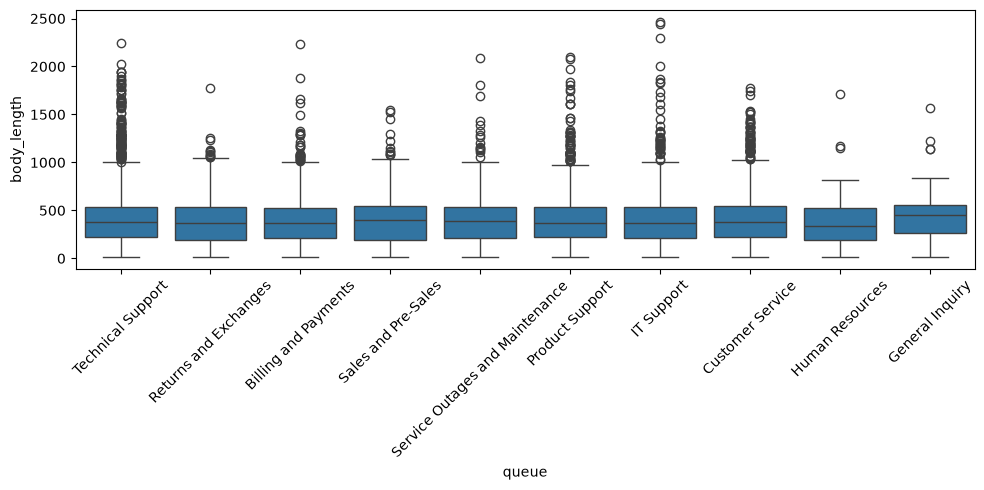

In [38]:
fig, ax = plt.subplots(figsize = (10,5))
ax  = sns.boxplot(data =df_new, x= "queue", y="body_length")
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

### Queue and priority distribution

The two prediction targets: `queue` (which department), `priority` (how urgent). Worth checking how balanced each is before modeling, since heavy imbalance affects both training and evaluation.

In [39]:
df_new["queue"].value_counts()

queue
Technical Support                  6230
Product Support                    3860
Customer Service                   3077
IT Support                         2529
Billing and Payments               2033
Returns and Exchanges              1066
Service Outages and Maintenance     845
Sales and Pre-Sales                 638
Human Resources                     417
General Inquiry                     287
Name: count, dtype: int64

### Relationship between queue and priority

A department's typical urgency might not be uniform - outages plausibly skew higher-priority than general inquiries, for instance. Checking the percentage breakdown of priority within each queue.

In [40]:
pd.crosstab(df_new["queue"], df_new["priority"]).sort_values(by="high", ascending=False)

priority,high,low,medium
queue,,,
Technical Support,3639,711,1880
IT Support,1207,235,1087
Product Support,1147,734,1979
Billing and Payments,615,434,984
Service Outages and Maintenance,604,97,144
Customer Service,568,1048,1461
Returns and Exchanges,234,411,421
Sales and Pre-Sales,113,234,291
Human Resources,46,205,166


In [41]:
pd.crosstab(df_new["queue"], df_new["priority"], normalize='index').sort_values(by="high", ascending=False)*100

priority,high,low,medium
queue,,,
Service Outages and Maintenance,71.479290,11.479290,17.041420
Technical Support,58.410915,11.412520,30.176565
IT Support,47.726374,9.292210,42.981416
Billing and Payments,30.250861,21.347762,48.401377
Product Support,29.715026,19.015544,51.269430
Returns and Exchanges,21.951220,38.555347,39.493433
Customer Service,18.459539,34.059149,47.481313
Sales and Pre-Sales,17.711599,36.677116,45.611285
General Inquiry,14.285714,57.491289,28.222997


#### Priority breakdown by department

```python
pd.crosstab(df_new['queue'], df_new['priority'], normalize='index') * 100
```

Row percentages make the pattern clearer than raw counts.

**Skewing toward "high":**
- `Service Outages and Maintenance`: 71.5% high
- `Technical Support`: 58.4% high
- `IT Support`: 47.7% high

**Skewing toward "low":**
- `General Inquiry`: 57.5% low
- `Human Resources`: 49.2% low
- `Returns and Exchanges`: 38.6% low

Everything else (Billing, Product Support, Customer Service, Sales) sits closer to medium/balanced. Makes intuitive sense — outages and technical problems are urgent by nature, general questions and HR rarely are. Raises a real modeling question: should `priority` see `queue` as a feature, or stay text-only and let the *language* of a ticket carry urgency on its own?

In [42]:
# Let's run a chi square to solidfy our assumption 

from scipy.stats import chi2_contingency
import pandas as pd

contingency_table = pd.crosstab(df_new["queue"], df_new["priority"])

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("Chi2 Stat:", chi2)
print("P-Value:  ", p_value)

sig_value = 0.05

if p_value < sig_value:
    print("Conclusion: Queue and Priority ARE associated with each other (Dependent).")
else:
    print("Conclusion: Queue and Priority ARE NOT associated with each other (Independent).")

    

Chi2 Stat: 3428.9456598313454
P-Value:   0.0
Conclusion: Queue and Priority ARE associated with each other (Dependent).


### Statistical test: queue and priority

Chi-square test of independence.

**H₀:** queue and priority are independent.
**H₁:** they're associated.

α = 0.05.

**Result: associated** - the null gets rejected.

### Relationship between ticket type, priority, and queue

In [43]:
pd.crosstab(df_new["type"], df_new["priority"]).sort_values(by="high", ascending=False)

priority,high,low,medium
type,,,
Incident,3727,1618,3342
Request,1893,1327,2492
Problem,1749,910,1809
Change,845,419,851


In [44]:
pd.crosstab(df_new["type"], df_new["queue"])

queue,Billing and Payments,Customer Service,General Inquiry,Human Resources,IT Support,Product Support,Returns and Exchanges,Sales and Pre-Sales,Service Outages and Maintenance,Technical Support
type,,,,,,,,,,
Change,120,230,82,22,431,426,136,109,188,371
Incident,508,806,86,226,958,1755,425,137,482,3304
Problem,459,676,57,44,618,870,222,85,60,1377
Request,946,1365,62,125,522,809,283,307,115,1178


In [45]:
from scipy.stats import chi2_contingency

table = pd.crosstab(df_new["type"], df_new["priority"])

chi2, p_value, dof, expected = chi2_contingency(table)

print("Chi2 Stat:", chi2)
print("P-Value:  ", p_value)

sig_value = 0.05

if p_value < sig_value:
    print("Conclusion: Type and Priority ARE associated with each other (Dependent).")
else:
    print("Conclusion: Type and Priority ARE NOT associated with each other (Independent).")

Chi2 Stat: 143.2308463420969
P-Value:   2.0841405392995557e-28
Conclusion: Type and Priority ARE associated with each other (Dependent).


In [46]:
from scipy.stats import chi2_contingency

table = pd.crosstab(df_new["type"], df_new["queue"])

chi2, p_value, dof, expected = chi2_contingency(table)

print("Chi2 Stat:", chi2)
print("P-Value:  ", p_value)

sig_value = 0.05

if p_value < sig_value:
    print("Conclusion: Queue and Type ARE associated with each other (Dependent).")
else:
    print("Conclusion: Queue and Type ARE NOT associated with each other (Independent).")

Chi2 Stat: 2393.5858676672588
P-Value:   0.0
Conclusion: Queue and Type ARE associated with each other (Dependent).


### Transition to NLP

EDA done: two source datasets combined cleanly, sparse metadata dropped, English-only tickets kept using detected (not just provided) language, missing values in core fields handled, and `queue`/`priority`/`type` all show real distributional differences worth carrying into modeling. Ready for the actual NLP pipeline.

In [47]:
# End of EDA
df_new.to_pickle("01_EDA.pkl")